In [1]:
!pip install -q git+https://github.com/RayenSansa03/aeroguard.git

from aeroguard.detection import score_z, detecter_anomalies, confirmer_alarmes, premiere_alarme
from aeroguard.data import table_vols
print("Package AeroGuard installé ✅")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Package AeroGuard installé ✅


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DOSSIER = "/content/drive/MyDrive/aeroguard"
os.makedirs(f"{DOSSIER}/results/figures", exist_ok=True)
N_VOLS_SAINS = 15

# Résidus par vol (leçon 1.5)
res_dev = pd.read_parquet(f"{DOSSIER}/data/processed/ds01_dev_residus_vols.parquet")
res_test = pd.read_parquet(f"{DOSSIER}/data/processed/ds01_test_residus_vols.parquet")

# Étiquettes par vol (avec ta fonction table_vols !)
cols = ["unit", "cycle", "hs", "RUL"]
etiq_dev = table_vols(pd.read_parquet(f"{DOSSIER}/data/processed/ds01_dev.parquet", columns=cols))
etiq_test = table_vols(pd.read_parquet(f"{DOSSIER}/data/processed/ds01_test.parquet", columns=cols))

dev = res_dev.merge(etiq_dev, on=["unit", "cycle"])
test = res_test.merge(etiq_test, on=["unit", "cycle"])
print(dev.shape, test.shape)

Mounted at /content/drive
(553, 19) (341, 19)


In [3]:
CAPTEUR = "T48"

reference = dev.loc[dev["cycle"] <= N_VOLS_SAINS, CAPTEUR]    # vols sains de DEV seulement
dev["z"] = score_z(dev[CAPTEUR], reference)
test["z"] = score_z(test[CAPTEUR], reference)                 # même référence, pas recalculée

print(f"Référence saine : moyenne = {reference.mean():.3f}, écart-type = {reference.std():.3f}")

Référence saine : moyenne = -0.106, écart-type = 0.814


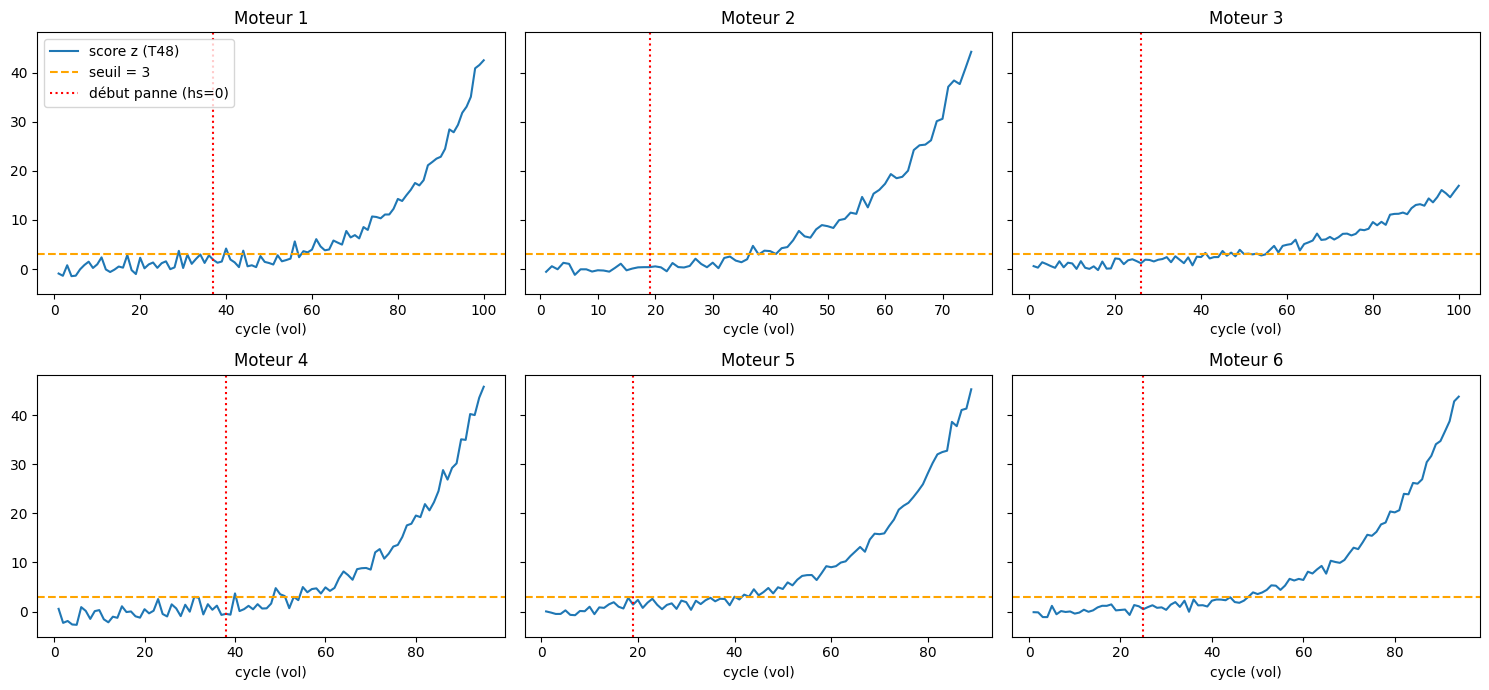

In [4]:
debut_panne = dev[dev["hs"] == 0].groupby("unit")["cycle"].min()

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
for ax, (u, m) in zip(axes.flat, dev.groupby("unit")):
    ax.plot(m["cycle"], m["z"], label="score z (T48)")
    ax.axhline(3, color="orange", linestyle="--", label="seuil = 3")
    ax.axvline(debut_panne[u], color="red", linestyle=":", label="début panne (hs=0)")
    ax.set_title(f"Moteur {u}")
    ax.set_xlabel("cycle (vol)")
axes.flat[0].legend()
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/16_score_z_T48.png", dpi=120)
plt.show()

In [5]:
def evaluer(vols, seuil=3.0, k=3):
    lignes = []
    for u, m in vols.groupby("unit"):
        m = m.sort_values("cycle").reset_index(drop=True)
        alarmes = detecter_anomalies(m["z"], seuil)
        pos = premiere_alarme(alarmes, k)
        debut = m.loc[m["hs"] == 0, "cycle"].min()

        if pos is None:
            lignes.append({"unit": u, "debut_panne": debut, "alarme_vol": None,
                           "avance_vols": 0, "fausse_alarme": False, "ratee": True})
        else:
            vol = m.loc[pos, "cycle"]
            lignes.append({"unit": u, "debut_panne": debut, "alarme_vol": vol,
                           "avance_vols": m.loc[pos, "RUL"],
                           "fausse_alarme": bool(m.loc[pos, "hs"] == 1),
                           "ratee": False})
    return pd.DataFrame(lignes)

resultats = evaluer(dev, seuil=3.0, k=3)
print(resultats)
print("\nAvance moyenne :", resultats["avance_vols"].mean().round(1), "vols")
print("Fausses alarmes :", resultats["fausse_alarme"].sum(), "/", len(resultats))
print("Pannes ratées   :", resultats["ratee"].sum(), "/", len(resultats))

   unit  debut_panne  alarme_vol  avance_vols  fausse_alarme  ratee
0     1           37          60           40          False  False
1     2           19          41           34          False  False
2     3           26          51           49          False  False
3     4           38          51           44          False  False
4     5           19          44           45          False  False
5     6           25          50           44          False  False

Avance moyenne : 42.7 vols
Fausses alarmes : 0 / 6
Pannes ratées   : 0 / 6


In [6]:
essais = []
for seuil in [2, 3, 4, 5]:
    for k in [1, 3, 5]:
        r = evaluer(dev, seuil, k)
        essais.append({"seuil": seuil, "k": k,
                       "avance_moy": r["avance_vols"].mean().round(1),
                       "fausses_alarmes": int(r["fausse_alarme"].sum()),
                       "ratees": int(r["ratee"].sum())})
tableau = pd.DataFrame(essais)
tableau

,seuil,k,avance_moy,fausses_alarmes,ratees
0,2,1,73.5,4,0
1,2,3,47.8,0,0
2,2,5,45.2,0,0
3,3,1,53.0,1,0
4,3,3,42.7,0,0
5,3,5,38.5,0,0
6,4,1,45.7,0,0
7,4,3,35.7,0,0
8,4,5,32.8,0,0
9,5,1,37.5,0,0


In [7]:
MEILLEUR_SEUIL, MEILLEUR_K = 3.0, 3      # ← mets tes valeurs

resultats_test = evaluer(test, MEILLEUR_SEUIL, MEILLEUR_K)
print(resultats_test)
print("\nTEST — avance moyenne :", resultats_test["avance_vols"].mean().round(1), "vols")
print("TEST — fausses alarmes :", resultats_test["fausse_alarme"].sum(), "/", len(resultats_test))
print("TEST — pannes ratées   :", resultats_test["ratee"].sum(), "/", len(resultats_test))

resultats_test.to_csv(f"{DOSSIER}/results/16_detection_test.csv", index=False)

   unit  debut_panne  alarme_vol  avance_vols  fausse_alarme  ratee
0     7           36          59           31          False  False
1     8           26          44           45          False  False
2     9           35          52           28          False  False
3    10           18          33           49          False  False

TEST — avance moyenne : 38.2 vols
TEST — fausses alarmes : 0 / 4
TEST — pannes ratées   : 0 / 4
